#### from txt to df to E


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
path = r"data\gelatin 10% F4\matrix_scan01\gelatin 10% F4 S-1 X-1 Y-1 I-1.txt"



# read text file tracking line until you find "Time (s)" then memorize that line and call it header_line
with open(path, 'r') as f:
    for i, line in enumerate(f):
        if "Time (s)" in line:
            header_line = i
            break
        if "E[eff]" in line:
            Youngs_modulus_line = i
            Youngs_modulus_value = float(line.strip().split('\t')[-1])


print(f"Header line found at line {header_line}: {line.strip()}")
print(f"Young's modulus found at line {Youngs_modulus_line} with value {Youngs_modulus_value} Pa or {Youngs_modulus_value/1e3} kPa")

# open txt file and read data into a pandas dataframe
data = pd.read_csv(path, sep='\t', header=header_line, skip_blank_lines=False)

display(data)


Header line found at line 34: Time (s)	Load (uN)	Indentation (nm)	Cantilever (nm)	Piezo (nm)	Auxiliary
Young's modulus found at line 31 with value 12429.103 Pa or 12.429103 kPa


,Time (s),Load (uN),Indentation (nm),Cantilever (nm),Piezo (nm),Auxiliary
0,0.000,-0.000638,0.0,-0.141728,-159.393512,-0.002382
1,0.001,-0.003981,0.0,-0.884745,-150.863869,-0.002322
2,0.002,-0.009580,0.0,-2.128850,-136.610611,-0.002362
3,0.003,-0.016473,0.0,-3.660627,-119.022908,-0.002302
4,0.004,-0.023891,0.0,-5.309060,-100.022814,-0.002403
...,...,...,...,...,...,...
6319,6.319,-0.094932,0.0,-21.096057,7.804650,-0.002403
6320,6.320,-0.094252,0.0,-20.944979,7.938984,-0.002403
6321,6.321,-0.093569,0.0,-20.793070,8.196036,-0.002322
6322,6.322,-0.092836,0.0,-20.630187,8.380522,-0.002403


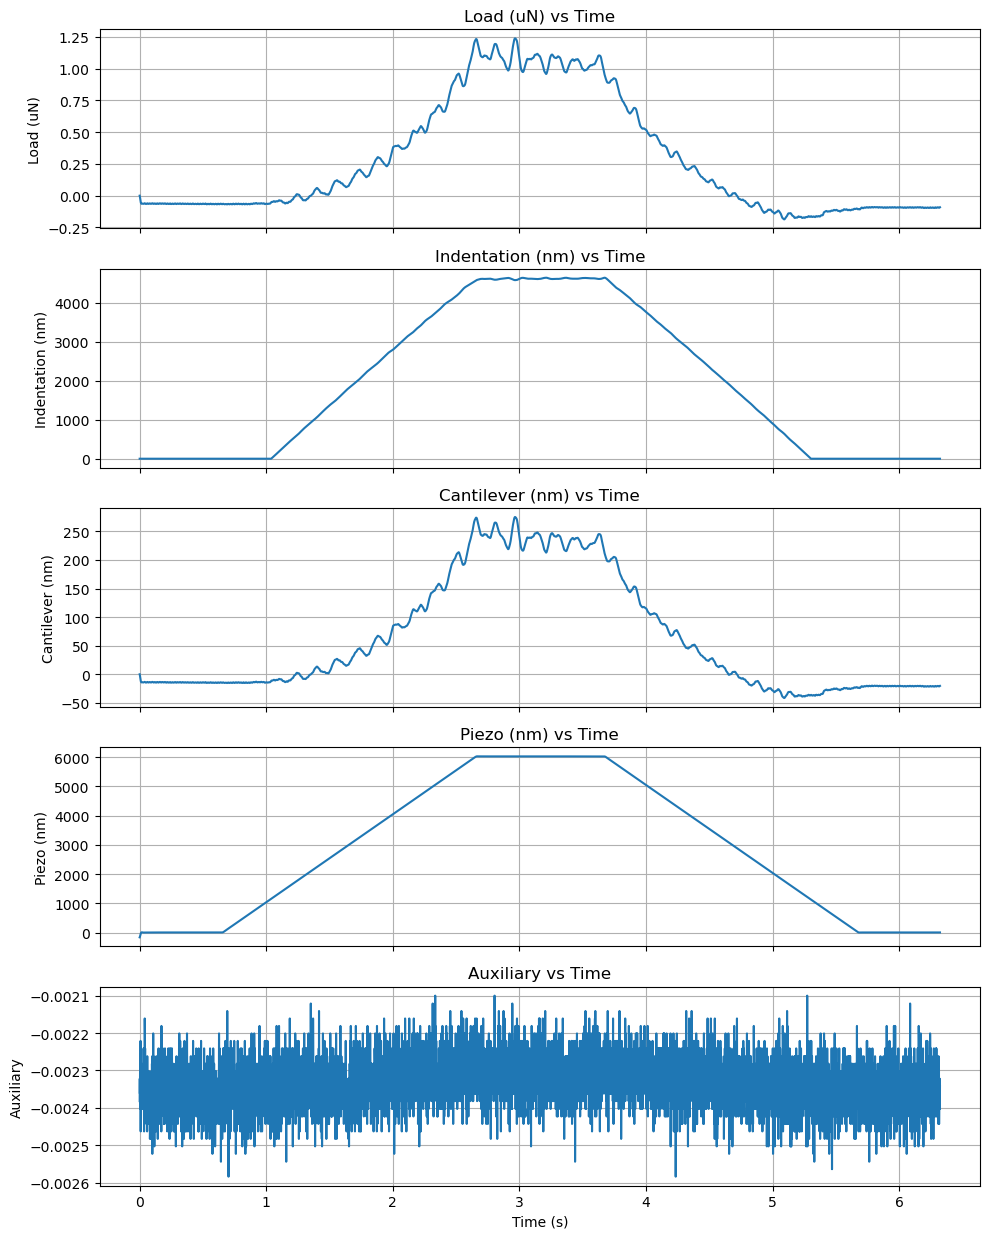

In [37]:
#plot a bit

#plot all variables against time

#with xkcd 


time_col = "Time (s)"
cols = [c for c in data.columns if c != time_col]
n = len(cols)
fig, axs = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)
if n == 1:
    axs = [axs]
for ax, col in zip(axs, cols):
    ax.plot(data[time_col], data[col])
    ax.set_title(f"{col} vs Time")
    ax.set_ylabel(col)
    ax.grid(True)
axs[-1].set_xlabel(time_col)
plt.tight_layout()
plt.show()

        

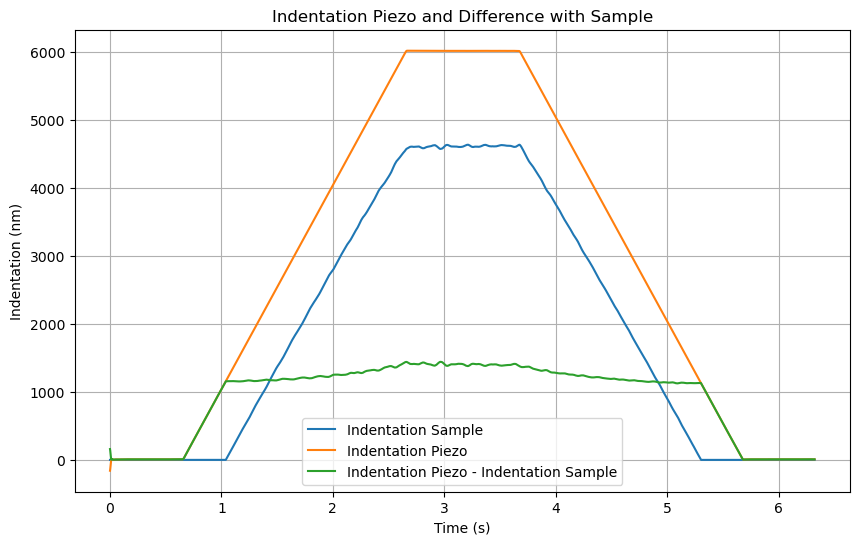

In [42]:
# plot indentation piezo and the substraction of both superimposed

plt.figure(figsize=(10, 6))
plt.plot(data[time_col], data["Indentation (nm)"], label="Indentation Sample")
plt.plot(data[time_col], data["Piezo (nm)"], label="Indentation Piezo")
plt.plot(data[time_col], abs(data["Indentation (nm)"] - data["Piezo (nm)"]), label="Indentation Piezo - Indentation Sample")
plt.title("Indentation Piezo and Difference with Sample")
plt.xlabel(time_col)
plt.ylabel("Indentation (nm)")
plt.legend()
plt.grid(True)
plt.show()


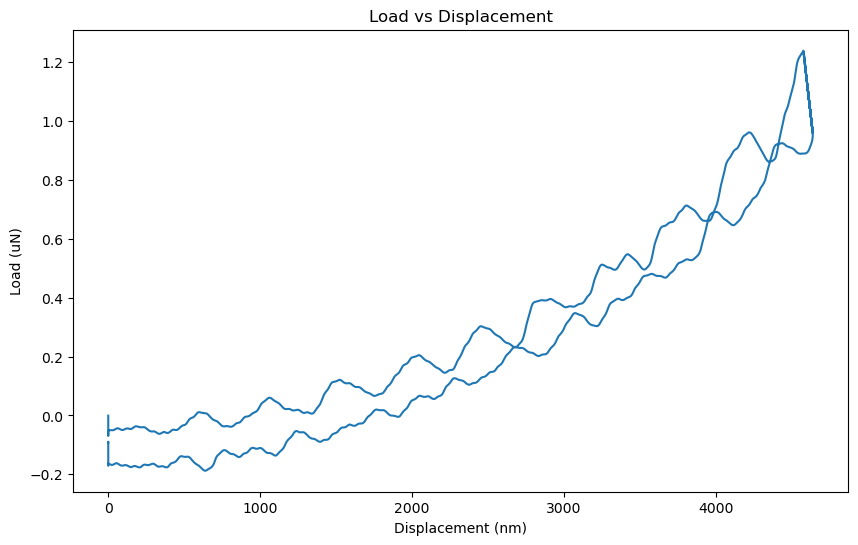

In [48]:
# plot load as a function of displacement

plt.figure(figsize=(10, 6))
plt.plot(data["Indentation (nm)"], data["Load (uN)"])
plt.title("Load vs Displacement")
plt.xlabel("Displacement (nm)")
plt.ylabel("Load (uN)")
plt.show()
